# Notebook 01. From DICOM archive to MI-CDM

**OHDSI Global Symposium 2026. Tutorial "Bringing FAIR to Imaging Research with the Medical Imaging OMOP Extension"**

**Hands-on I (09:00–09:45)**

In this notebook you take a small archive of real chest radiographs (RSNA Pneumonia Detection Challenge) and turn their DICOM headers into an OMOP CDM v5.4 database extended with the **Medical Imaging CDM (MI-CDM)**.

The notebook follows the [ImageWG implementation flowchart](https://github.com/OHDSI/ImageWG/wiki/Medical-Imaging-Extension-Conventions) step by step, and the code follows the [DICOM2OMOP demonstration](https://github.com/paulnagy/DICOM2OMOP/tree/main/demonstration) notebooks.

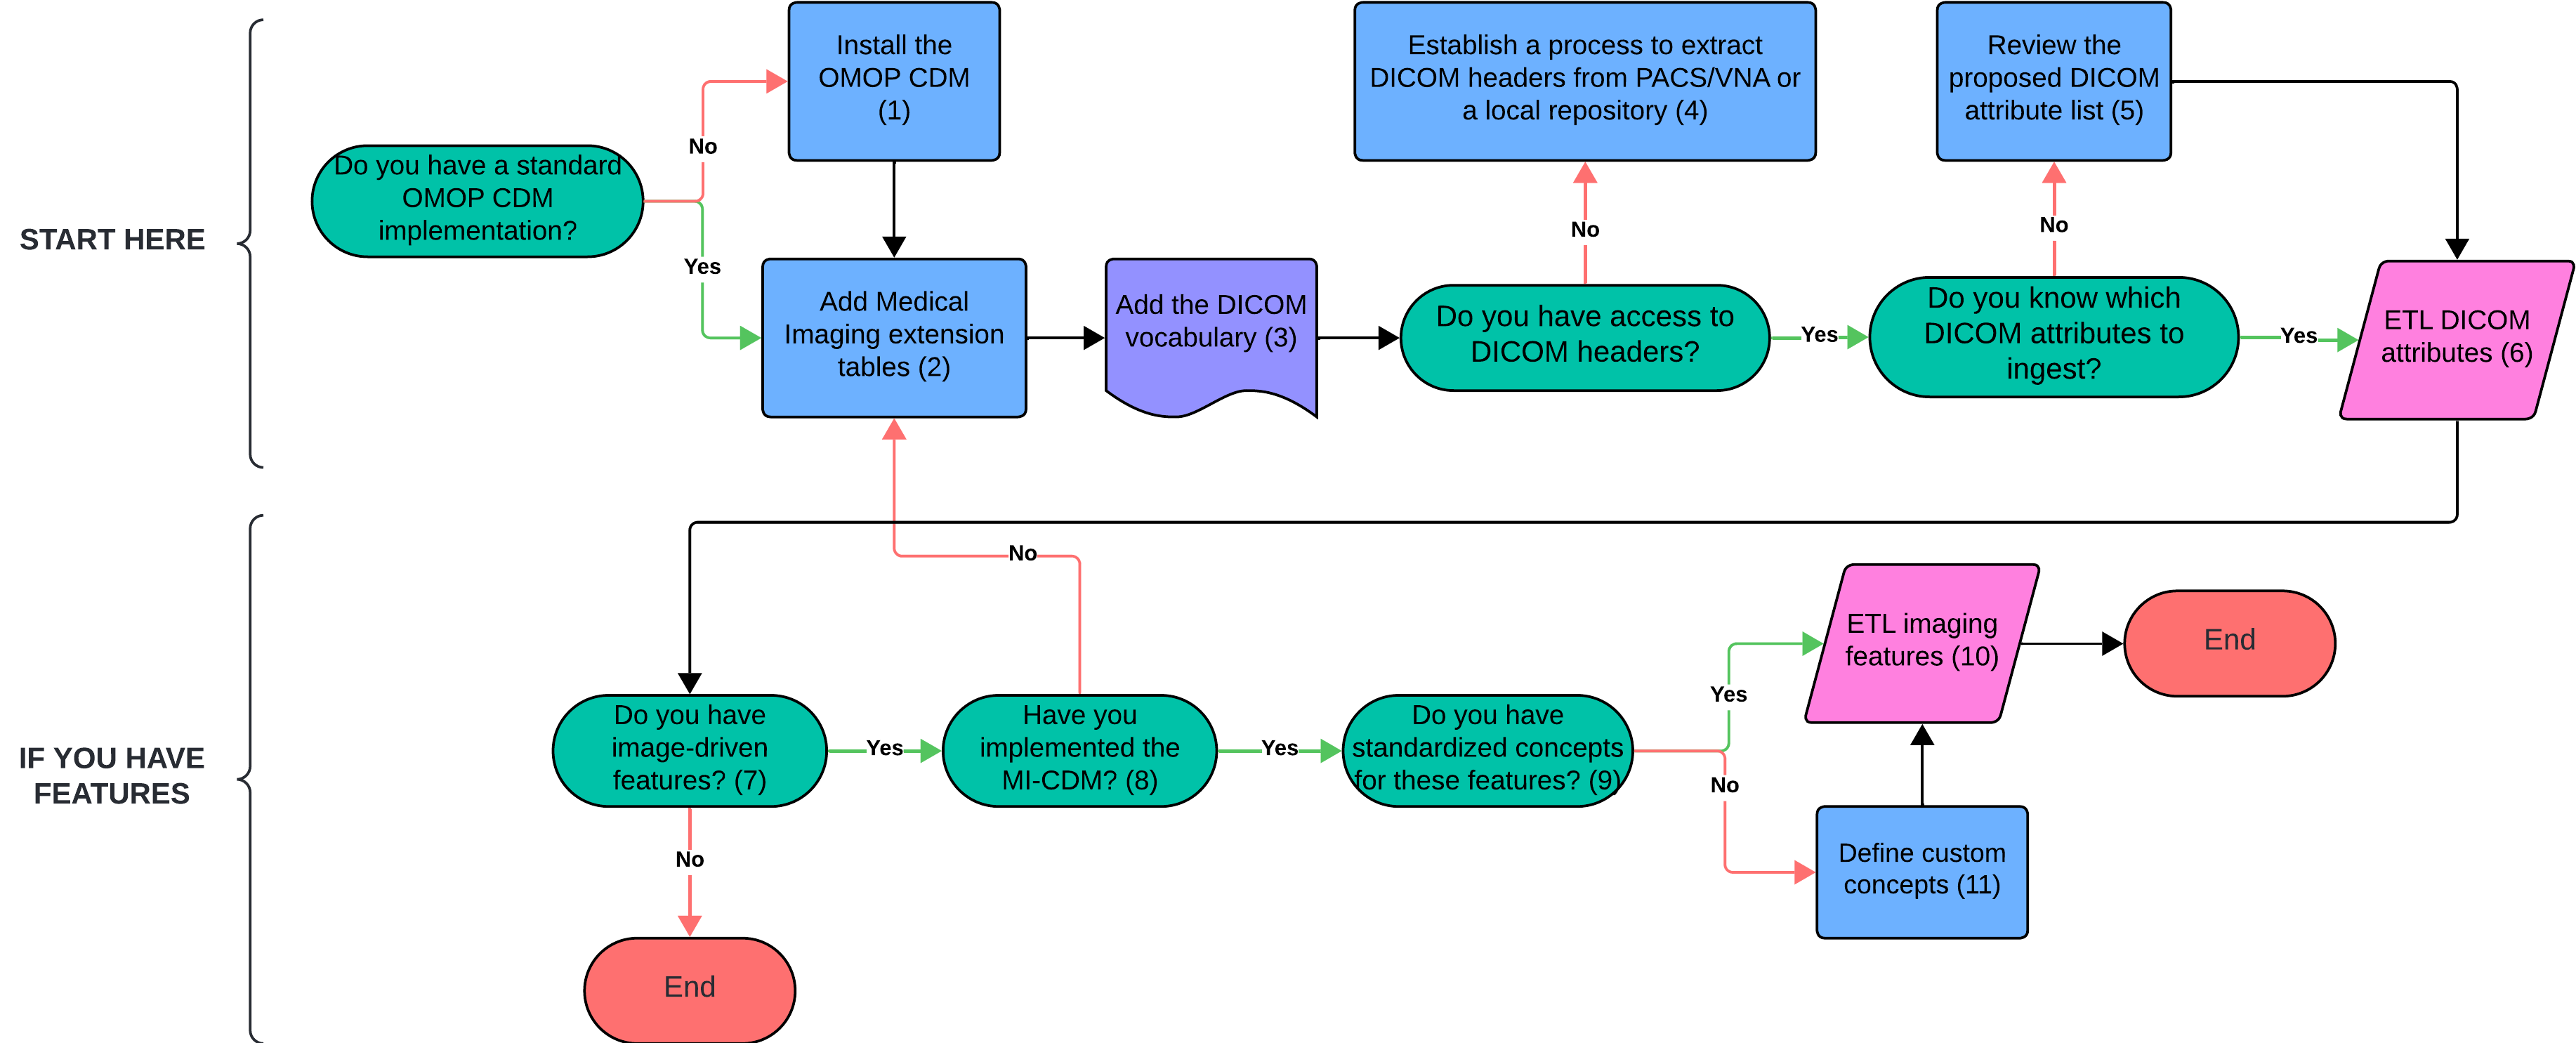

| Wiki step | Section | DICOM2OMOP counterpart |
|---|---|---|
| 1. Install OMOP | 1 | — |
| 2. Add MI-CDM tables | 2 | `build_imaging_extension.ipynb` |
| 3. Add DICOM vocabulary | 3 | `load_dicom_to_omop.ipynb` (`omop_table_staging_v5.csv`) |
| 4. Extract DICOM headers | 4 | `extract_ADNI_images.ipynb` |
| 5. Review attribute list | 5 | `transform_imaging_metadata.ipynb` (tag selection) |
| 6. ETL DICOM attributes | 6 | `transform_imaging_metadata.ipynb` + `load_imaging_data.ipynb` |
| ETL guide §9. Data quality | 7 | — |

**Notebook series**

| Notebook | Session | Builds |
|---|---|---|
| **01. DICOM → MI-CDM** (this one) | Hands-on I | `PERSON`, `PROCEDURE_OCCURRENCE`, `IMAGE_OCCURRENCE`, `MEASUREMENT` (DICOM attributes) |
| 02. Image-derived features | Hands-on II | `IMAGE_FEATURE`, `MEASUREMENT` (AI outputs), provenance |

Everything is written to one SQLite file. Notebooks 0 rebuild it automatically if you open them in a fresh runtime.

**How to run:** `Runtime → Run all`, then read along section by section. The whole notebook takes about 5 minutes (most of it is the download).

## 0. Setup

In [ ]:
%pip install -q "pydicom>=3.0" pylibjpeg pylibjpeg-libjpeg remotezip

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [0](https://athena.ohdsi.org/search-terms/terms/0) | No matching concept | Metadata | None | Undefined | No matching concept |
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |
| [4163872](https://athena.ohdsi.org/search-terms/terms/4163872) | Plain X-ray of chest | Procedure | SNOMED | Procedure | 399208008 |
| [8507](https://athena.ohdsi.org/search-terms/terms/8507) | MALE | Gender | Gender | Gender | M |
| [8532](https://athena.ohdsi.org/search-terms/terms/8532) | FEMALE | Gender | Gender | Gender | F |
| [8588](https://athena.ohdsi.org/search-terms/terms/8588) | millimeter | Unit | UCUM | Unit | mm |
| [1147330](https://athena.ohdsi.org/search-terms/terms/1147330) | measurement | Metadata | CDM | Table | CDM386 |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0008,0070) | Manufacturer | 2128000056 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0030) | Pixel Spacing | 2128002096 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0018,1164) | Imager Pixel Spacing | 2128000944 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0018,0050) | Slice Thickness | 2128000817 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0018,1110) | Distance Source to Detector | 2128000910 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0018,1111) | Distance Source to Patient | 2128000911 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |

In [ ]:
# Configuration. Re-run this cell after a runtime restart; every later cell relies on it.
import os, re, glob, json, sqlite3, datetime, warnings, urllib.request
import pandas as pd

warnings.filterwarnings("ignore", message="Invalid value for VR")   # RSNA stores PatientAge as a bare integer
pd.set_option("display.max_colwidth", 60)

BASE_DIR = os.environ.get(
    "MICDM_BASE",
    "/content/micdm_tutorial" if os.path.isdir("/content") else os.path.abspath("./micdm_tutorial"))
DB_PATH = os.path.join(BASE_DIR, "omop_micdm.db")
DICOM_DIR = os.path.join(BASE_DIR, "dicom")
VOCAB_DIR = os.path.join(BASE_DIR, "vocab")
for _d in (BASE_DIR, DICOM_DIR, VOCAB_DIR):
    os.makedirs(_d, exist_ok=True)

# ---- tutorial-scale knobs ------------------------------------------------------------
N_IMAGES = int(os.environ.get("MICDM_N_IMAGES", 100))   # keep 50–200 in the session
SUBSET_OFFSET = 0                                          # sorted file list -> same images for everyone
RSNA_ZIP_URL = ("https://s3.amazonaws.com/east1.public.rsna.org/AI/2018/"
                "pneumonia-challenge-dataset-adjudicated-kaggle_2018.zip")

# ---- DICOM vocabulary: DICOM2OMOP staging files, pinned to one commit for reproducibility
DICOM2OMOP_COMMIT = "56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88"
DICOM2OMOP_RAW = ("https://raw.githubusercontent.com/paulnagy/DICOM2OMOP/"
                  f"{DICOM2OMOP_COMMIT}/files/OMOP%20CDM%20Staging/")
VOCAB_FILES = {
    "concept": "omop_table_staging_v5.csv",           # DICOM attributes + CS value sets (2128xxxxxx)
    "maps_to_value": "cs_values_maps_to_value.csv",   # attribute  --Maps to value-->  value
    "maps_to": "cs_values_maps_to.csv",               # value      --Maps to-->        standard (SNOMED)
}
DICOM_CONCEPT_RANGE = (2128000000, 2128999999)

# ---- concepts fixed by OMOP / the ImageWG conventions ---------------------------------
CONCEPT_UNMAPPED = 0
CONCEPT_TYPE_EHR = 32817            # Type Concept 'EHR'
CONCEPT_CHEST_XRAY = 4163872        # SNOMED 399208008 'Plain X-ray of chest' (Procedure)
CONCEPT_MALE, CONCEPT_FEMALE = 8507, 8532
CONCEPT_UNIT_MM = 8588              # UCUM 'mm'
EVENT_FIELD_MEASUREMENT = 1147330   # ETL guide §7: image_feature -> MEASUREMENT

# meas_event_field_concept_id for rows linked to IMAGE_OCCURRENCE. The CDM vocabulary has no
# Field concept for image_occurrence.image_occurrence_id yet, so 0 ('No matching concept') is
# written until the ImageWG designates one. The link itself is measurement_event_id.
FIELD_IMAGE_OCCURRENCE_ID = CONCEPT_UNMAPPED

# ---- DICOM2OMOP attribute-selection rules (transform_imaging_metadata.ipynb) ------------
MEASURABLE_VRS = ["AT", "CS", "DA", "DT", "DS", "FL", "FD", "IS", "SL", "SS", "SV", "TM", "UL", "US", "UV"]
NUMERIC_VRS = ["DS", "FL", "FD", "IS", "SL", "SS", "SV", "UL", "US", "UV"]
ALWAYS_INCLUDE_TAGS = ["00080070"]       # Manufacturer (LO), kept by DICOM2OMOP for analysis
MAX_VALUE_LEN = 50
# ETL guide §4: attributes that populate IMAGE_OCCURRENCE (not repeated in MEASUREMENT)
CORE_TAGS = {"00080020": "Study Date", "00100020": "Patient ID", "00080060": "Modality",
             "00180015": "Body Part Examined", "0020000D": "Study Instance UID",
             "0020000E": "Series Instance UID"}
UNIT_BY_TAG = {"00280030": CONCEPT_UNIT_MM,   # Pixel Spacing
               "00181164": CONCEPT_UNIT_MM,   # Imager Pixel Spacing
               "00180050": CONCEPT_UNIT_MM,   # Slice Thickness
               "00181110": CONCEPT_UNIT_MM,   # Distance Source to Detector
               "00181111": CONCEPT_UNIT_MM}   # Distance Source to Patient


def connect(db_path=None):
    conn = sqlite3.connect(db_path or DB_PATH)
    conn.execute("PRAGMA foreign_keys = ON")
    return conn


def q(sql, params=()):
    """Run a read-only query and return a DataFrame."""
    with connect() as conn:
        return pd.read_sql_query(sql, conn, params=params)
# ▶ run
print("database :", DB_PATH)
print("DICOM dir:", DICOM_DIR)
print("images   :", N_IMAGES)

database : /content/micdm_tutorial/omop_micdm.db
DICOM dir: /content/micdm_tutorial/dicom
images   : 100


## 1. Wiki step 1 — an OMOP CDM to extend

At your site this already exists. Here we create the handful of OMOP CDM v5.4 tables the tutorial needs, in SQLite, with column names and nullability from the [CDM v5.4 DDL](https://ohdsi.github.io/CommonDataModel/cdm54.html). Foreign keys are switched on so broken links fail loudly.

In [ ]:
CDM_DDL = """
CREATE TABLE IF NOT EXISTS concept (
    concept_id        INTEGER NOT NULL PRIMARY KEY,
    concept_name      VARCHAR(255) NOT NULL,
    domain_id         VARCHAR(20)  NOT NULL,
    vocabulary_id     VARCHAR(20)  NOT NULL,
    concept_class_id  VARCHAR(20)  NOT NULL,
    standard_concept  VARCHAR(1),
    concept_code      VARCHAR(50)  NOT NULL,
    valid_start_date  DATE NOT NULL,
    valid_end_date    DATE NOT NULL,
    invalid_reason    VARCHAR(1));

CREATE TABLE IF NOT EXISTS concept_relationship (
    concept_id_1      INTEGER NOT NULL,
    concept_id_2      INTEGER NOT NULL,
    relationship_id   VARCHAR(20) NOT NULL,
    valid_start_date  DATE NOT NULL,
    valid_end_date    DATE NOT NULL,
    invalid_reason    VARCHAR(1),
    PRIMARY KEY (concept_id_1, concept_id_2, relationship_id));

CREATE TABLE IF NOT EXISTS person (
    person_id                   INTEGER NOT NULL PRIMARY KEY,
    gender_concept_id           INTEGER NOT NULL,
    year_of_birth               INTEGER NOT NULL,
    month_of_birth              INTEGER,
    day_of_birth                INTEGER,
    birth_datetime              TIMESTAMP,
    race_concept_id             INTEGER NOT NULL,
    ethnicity_concept_id        INTEGER NOT NULL,
    location_id                 INTEGER,
    provider_id                 INTEGER,
    care_site_id                INTEGER,
    person_source_value         VARCHAR(50),
    gender_source_value         VARCHAR(50),
    gender_source_concept_id    INTEGER,
    race_source_value           VARCHAR(50),
    race_source_concept_id      INTEGER,
    ethnicity_source_value      VARCHAR(50),
    ethnicity_source_concept_id INTEGER);

CREATE TABLE IF NOT EXISTS observation_period (
    observation_period_id         INTEGER NOT NULL PRIMARY KEY,
    person_id                     INTEGER NOT NULL REFERENCES person (person_id),
    observation_period_start_date DATE NOT NULL,
    observation_period_end_date   DATE NOT NULL,
    period_type_concept_id        INTEGER NOT NULL);

CREATE TABLE IF NOT EXISTS procedure_occurrence (
    procedure_occurrence_id     INTEGER NOT NULL PRIMARY KEY,
    person_id                   INTEGER NOT NULL REFERENCES person (person_id),
    procedure_concept_id        INTEGER NOT NULL,
    procedure_date              DATE NOT NULL,
    procedure_datetime          TIMESTAMP,
    procedure_end_date          DATE,
    procedure_end_datetime      TIMESTAMP,
    procedure_type_concept_id   INTEGER NOT NULL,
    modifier_concept_id         INTEGER,
    quantity                    INTEGER,
    provider_id                 INTEGER,
    visit_occurrence_id         INTEGER,
    visit_detail_id             INTEGER,
    procedure_source_value      VARCHAR(50),
    procedure_source_concept_id INTEGER,
    modifier_source_value       VARCHAR(50));

CREATE TABLE IF NOT EXISTS measurement (
    measurement_id                INTEGER NOT NULL PRIMARY KEY,
    person_id                     INTEGER NOT NULL REFERENCES person (person_id),
    measurement_concept_id        INTEGER NOT NULL,
    measurement_date              DATE NOT NULL,
    measurement_datetime          TIMESTAMP,
    measurement_time              VARCHAR(10),
    measurement_type_concept_id   INTEGER NOT NULL,
    operator_concept_id           INTEGER,
    value_as_number               NUMERIC,
    value_as_concept_id           INTEGER,
    unit_concept_id               INTEGER,
    range_low                     NUMERIC,
    range_high                    NUMERIC,
    provider_id                   INTEGER,
    visit_occurrence_id           INTEGER,
    visit_detail_id               INTEGER,
    measurement_source_value      VARCHAR(50),
    measurement_source_concept_id INTEGER,
    unit_source_value             VARCHAR(50),
    unit_source_concept_id        INTEGER,
    value_source_value            VARCHAR(50),
    measurement_event_id          INTEGER,
    meas_event_field_concept_id   INTEGER);
CREATE INDEX IF NOT EXISTS idx_measurement_event ON measurement (measurement_event_id, meas_event_field_concept_id);
CREATE INDEX IF NOT EXISTS idx_measurement_concept ON measurement (measurement_concept_id);
"""


def create_cdm_tables(conn):
    conn.executescript(CDM_DDL)
# ▶ run
# Start notebook 01 from an empty database. Rows from an earlier run in the same runtime
# (e.g. concepts written by an older version of this notebook) would otherwise stay in SQLite.
RESET_DB = True
if RESET_DB and os.path.exists(DB_PATH):
    os.remove(DB_PATH)
    print("removed existing database:", DB_PATH)
with connect() as conn:
    create_cdm_tables(conn)
q("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")

removed existing database: /content/micdm_tutorial/omop_micdm.db


,name
0,concept
1,concept_relationship
2,measurement
3,observation_period
4,person
5,procedure_occurrence


## 2. Wiki step 2 — add the MI-CDM tables

The two extension tables, **column-for-column as published on the wiki**. Only the SQLite types and the foreign-key clauses are added.

* `IMAGE_OCCURRENCE` — the imaging catalog. **One row per DICOM series**, linked to `PERSON` and to the `PROCEDURE_OCCURRENCE` that produced it.
* `IMAGE_FEATURE` — findings and features derived from an image (used in notebook 02). It stores *what* and *where*; values live in `MEASUREMENT`.

In [ ]:
MICDM_DDL = """
CREATE TABLE IF NOT EXISTS image_occurrence (
    image_occurrence_id       INTEGER NOT NULL PRIMARY KEY,
    person_id                 INTEGER NOT NULL REFERENCES person (person_id),
    procedure_occurrence_id   INTEGER NOT NULL REFERENCES procedure_occurrence (procedure_occurrence_id),
    visit_occurrence_id       INTEGER,
    anatomic_site_concept_id  INTEGER,
    wadors_uri                VARCHAR(10000),
    local_path                VARCHAR(10000),
    image_occurrence_date     DATE NOT NULL,
    image_study_uid           VARCHAR(10000) NOT NULL,
    image_series_uid          VARCHAR(10000) NOT NULL,
    modality_concept_id       INTEGER NOT NULL);

CREATE TABLE IF NOT EXISTS image_feature (
    image_feature_id                      INTEGER NOT NULL PRIMARY KEY,
    person_id                             INTEGER NOT NULL REFERENCES person (person_id),
    image_occurrence_id                   INTEGER NOT NULL REFERENCES image_occurrence (image_occurrence_id),
    image_feature_event_field_concept_id  INTEGER,
    image_feature_event_id                INTEGER,
    image_feature_concept_id              INTEGER NOT NULL,
    image_feature_type_concept_id         INTEGER NOT NULL,
    image_finding_concept_id              INTEGER,
    image_finding_id                      INTEGER,
    anatomic_site_concept_id              INTEGER,
    alg_system                            VARCHAR(10000),
    alg_datetime                          TIMESTAMP);
CREATE UNIQUE INDEX IF NOT EXISTS idx_image_occurrence_series ON image_occurrence (image_study_uid, image_series_uid);
CREATE INDEX IF NOT EXISTS idx_image_feature_image ON image_feature (image_occurrence_id);
"""

# Tables written by the ETL, parent -> child. Re-running a step clears that table and
# everything downstream of it, so foreign keys never dangle.
ETL_TABLE_ORDER = ["person", "observation_period", "procedure_occurrence",
                   "image_occurrence", "measurement", "image_feature"]


def create_micdm_tables(conn):
    conn.executescript(MICDM_DDL)


def clear_from(conn, table):
    """Delete `table` and every ETL table downstream of it (children first)."""
    downstream = ETL_TABLE_ORDER[ETL_TABLE_ORDER.index(table):]
    for t in reversed(downstream):
        if t == "observation_period" and table not in ("person", "observation_period"):
            continue                                   # not a child of procedure/image tables
        conn.execute(f"DELETE FROM {t}")
    return downstream
# ▶ run
with connect() as conn:
    create_micdm_tables(conn)
q("PRAGMA table_info(image_occurrence)")[["name", "type", "notnull"]]

,name,type,notnull
0,image_occurrence_id,INTEGER,1
1,person_id,INTEGER,1
2,procedure_occurrence_id,INTEGER,1
3,visit_occurrence_id,INTEGER,0
4,anatomic_site_concept_id,INTEGER,0
5,wadors_uri,VARCHAR(10000),0
6,local_path,VARCHAR(10000),0
7,image_occurrence_date,DATE,1
8,image_study_uid,VARCHAR(10000),1
9,image_series_uid,VARCHAR(10000),1


## 3. Wiki step 3 — load the DICOM vocabulary

The ETL guide (§3.1) says to load the custom DICOM concepts **before** transforming anything. They come from the DICOM2OMOP staging file `omop_table_staging_v5.csv`, plus two relationship files:

```
attribute  2128000792  Body Part Examined          (DICOM Attributes, tag 00180015)
   └─ Maps to value ─▶ 2128009433  Chest            (DICOM Value Sets, code CHEST)
                          └─ Maps to ─▶ 4184181  SNOMED standard anatomic site
```

* **Attributes** (5,183 concepts): one per DICOM tag. `concept_code` is the tag (`00180015`).
* **Value sets** (3,628 concepts): coded-string (CS) values such as `CR` or `CHEST`.
* All DICOM concepts are **non-standard** (`standard_concept` is empty) and live in `2128000000–2128999999`.

Everything is downloaded from GitHub at a pinned commit, so every participant loads the same vocabulary.

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [0](https://athena.ohdsi.org/search-terms/terms/0) | No matching concept | Metadata | None | Undefined | No matching concept |
| [8507](https://athena.ohdsi.org/search-terms/terms/8507) | MALE | Gender | Gender | Gender | M |
| [8532](https://athena.ohdsi.org/search-terms/terms/8532) | FEMALE | Gender | Gender | Gender | F |
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |
| [4163872](https://athena.ohdsi.org/search-terms/terms/4163872) | Plain X-ray of chest | Procedure | SNOMED | Procedure | 399208008 |
| [4184181](https://athena.ohdsi.org/search-terms/terms/4184181) | Thoracic cavity structure | Spec Anatomic Site | SNOMED | Body Structure | 43799004 |
| [4213162](https://athena.ohdsi.org/search-terms/terms/4213162) | Lung structure | Spec Anatomic Site | SNOMED | Body Structure | 39607008 |
| [8588](https://athena.ohdsi.org/search-terms/terms/8588) | millimeter | Unit | UCUM | Unit | mm |
| [1147330](https://athena.ohdsi.org/search-terms/terms/1147330) | measurement | Metadata | CDM | Table | CDM386 |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| — | All DICOM attributes and CS value sets | 2128000000–2128999999 | DICOM2OMOP `omop_table_staging_v5.csv` |

In [ ]:
# Standard concepts the tutorial refers to. This is a *display subset* so queries can show
# names — it is not a substitute for loading the Athena vocabularies at your site.
STANDARD_CONCEPTS = [
    # concept_id, name, domain, vocabulary, class, standard, code
    (0, "No matching concept", "Metadata", "None", "Undefined", None, "No matching concept"),
    (8507, "MALE", "Gender", "Gender", "Gender", "S", "M"),
    (8532, "FEMALE", "Gender", "Gender", "Gender", "S", "F"),
    (32817, "EHR", "Type Concept", "Type Concept", "Type Concept", "S", "OMOP4976890"),
    (4163872, "Plain X-ray of chest", "Procedure", "SNOMED", "Procedure", "S", "399208008"),
    (4184181, "Thoracic cavity structure", "Spec Anatomic Site", "SNOMED", "Body Structure", "S", "43799004"),
    (4213162, "Lung structure", "Spec Anatomic Site", "SNOMED", "Body Structure", "S", "39607008"),
    (8588, "millimeter", "Unit", "UCUM", "Unit", "S", "mm"),
    (1147330, "measurement", "Metadata", "CDM", "Table", "S", "CDM386"),
]


def download_vocabulary(vocab_dir=None):
    vocab_dir = vocab_dir or VOCAB_DIR
    paths = {}
    for key, fname in VOCAB_FILES.items():
        dest = os.path.join(vocab_dir, fname)
        if not os.path.exists(dest):
            urllib.request.urlretrieve(DICOM2OMOP_RAW + fname, dest)
        paths[key] = dest
    return paths


def _yyyymmdd_to_iso(s):
    s = str(s)
    return f"{s[:4]}-{s[4:6]}-{s[6:8]}" if len(s) == 8 and s.isdigit() else s


def insert_concepts(conn, rows):
    conn.executemany(
        """INSERT OR REPLACE INTO concept (concept_id, concept_name, domain_id, vocabulary_id,
               concept_class_id, standard_concept, concept_code, valid_start_date,
               valid_end_date, invalid_reason)
           VALUES (?,?,?,?,?,?,?,'1970-01-01','2099-12-31',NULL)""", rows)


def load_dicom_vocabulary(conn, paths):
    concept = pd.read_csv(paths["concept"], dtype=str)
    concept = concept.where(concept.notna(), None)
    concept["valid_start_date"] = concept["valid_start_date"].map(_yyyymmdd_to_iso)
    concept["valid_end_date"] = concept["valid_end_date"].map(_yyyymmdd_to_iso)
    cols = ["concept_id", "concept_name", "domain_id", "vocabulary_id", "concept_class_id",
            "standard_concept", "concept_code", "valid_start_date", "valid_end_date", "invalid_reason"]
    conn.executemany(f"INSERT OR REPLACE INTO concept ({', '.join(cols)}) VALUES ({', '.join('?' * len(cols))})",
                     concept[cols].itertuples(index=False, name=None))

    rel = pd.concat([pd.read_csv(paths["maps_to_value"]), pd.read_csv(paths["maps_to"])])
    conn.execute("DELETE FROM concept_relationship WHERE concept_id_1 BETWEEN ? AND ?", DICOM_CONCEPT_RANGE)
    conn.executemany(
        """INSERT OR REPLACE INTO concept_relationship
           (concept_id_1, concept_id_2, relationship_id, valid_start_date, valid_end_date, invalid_reason)
           VALUES (?,?,?,'1970-01-01','2099-12-31',NULL)""",
        rel[["concept_id_1", "concept_id_2", "relationship_id"]].itertuples(index=False, name=None))
    insert_concepts(conn, STANDARD_CONCEPTS)
    return len(concept), len(rel)
# ▶ run
vocab_paths = download_vocabulary()
with connect() as conn:
    n_concepts, n_rels = load_dicom_vocabulary(conn, vocab_paths)
print(f"DICOM concepts loaded: {n_concepts:,}   relationships: {n_rels:,}")
q("""SELECT vocabulary_id, concept_class_id, COUNT(*) AS n
     FROM concept GROUP BY vocabulary_id, concept_class_id ORDER BY n DESC""")

DICOM concepts loaded: 8,811   relationships: 1,052


,vocabulary_id,concept_class_id,n
0,DICOM,DICOM Attributes,5183
1,DICOM,DICOM Value Sets,3628
2,Gender,Gender,2
3,SNOMED,Body Structure,2
4,CDM,Table,1
5,None,Undefined,1
6,SNOMED,Procedure,1
7,Type Concept,Type Concept,1
8,UCUM,Unit,1


**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [4184181](https://athena.ohdsi.org/search-terms/terms/4184181) | Thoracic cavity structure | Spec Anatomic Site | SNOMED | Body Structure | 43799004 |
| [4213162](https://athena.ohdsi.org/search-terms/terms/4213162) | Lung structure | Spec Anatomic Site | SNOMED | Body Structure | 39607008 |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0018,0015) | Body Part Examined | 2128000792 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0018,0015) | Body Part Examined = `CHEST` (Chest) | 2128009433 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |
| (0018,0015) | Body Part Examined = `THORAX` (Thorax) | 2128009674 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |
| (0018,0015) | Body Part Examined = `LUNG` (Lung) | 2128009558 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |

In [ ]:
# The attribute -> value -> standard chain for Body Part Examined = CHEST
q("""
SELECT a.concept_id AS attribute_id, a.concept_name AS attribute, a.concept_code AS tag,
       v.concept_id AS value_id, v.concept_code AS value_code,
       s.concept_id AS standard_id, s.concept_name AS standard_name
FROM concept a
JOIN concept_relationship r1 ON r1.concept_id_1 = a.concept_id AND r1.relationship_id = 'Maps to value'
JOIN concept v               ON v.concept_id = r1.concept_id_2
LEFT JOIN concept_relationship r2 ON r2.concept_id_1 = v.concept_id AND r2.relationship_id = 'Maps to'
LEFT JOIN concept s          ON s.concept_id = r2.concept_id_2
WHERE a.concept_code = '00180015' AND v.concept_code IN ('CHEST', 'THORAX', 'LUNG')
""")

,attribute_id,attribute,tag,value_id,value_code,standard_id,standard_name
0,2128000792,Body Part Examined,00180015,2128009433,CHEST,4184181,Thoracic cavity structure
1,2128000792,Body Part Examined,00180015,2128009558,LUNG,4213162,Lung structure
2,2128000792,Body Part Examined,00180015,2128009674,THORAX,4184181,Thoracic cavity structure


**Only a few attributes have value sets.** Most CS attributes (e.g. *View Position*, *Patient's Sex*, *Photometric Interpretation*) have no `Maps to value` rows in the staging file. We will come back to this in section 6d.

In [ ]:
q("""
SELECT a.concept_name AS attribute, a.concept_code AS tag, COUNT(*) AS n_values
FROM concept_relationship r JOIN concept a ON a.concept_id = r.concept_id_1
WHERE r.relationship_id = 'Maps to value'
GROUP BY a.concept_id ORDER BY n_values DESC
""")

,attribute,tag,n_values
0,Body Part Examined,00180015,318
1,Anatomic Region Sequence,00082218,318
2,Modality,00080060,79
3,Patient Position,00185100,16
4,Lossy Image Compression Method,00282114,8


## 4. Wiki step 4 — extract DICOM headers

MI-CDM needs **metadata only**, never pixels. This step has three parts:

* **4a. Get the files.** At your site: a PACS/VNA query or a file share. Here: 100 files from the public RSNA archive, pulled by HTTP range requests so we never download the 4 GB zip.
* **4b. Index the archive.** Build an inventory: patient → study → series → instance.
* **4c. Extract the headers.** One representative instance per series, flattened to *(StudyUID, SeriesUID, Tag, VR, Value)* rows — the same long format DICOM2OMOP produces from DICOMweb.

**Dataset:** RSNA Pneumonia Detection Challenge (2018). Use for research and education is permitted with attribution: Shih G, *et al.* *Radiol Artif Intell* 2019;1(1):e180041, and Wang X, *et al.* ChestX-ray8, CVPR 2017. Images are fetched at run time, not redistributed.

In [ ]:
def download_rsna_subset(dest=None, n_images=None, offset=None, url=RSNA_ZIP_URL):
    """Pull n_images .dcm members out of the remote ZIP. Skips the download if enough files exist."""
    dest, n_images = dest or DICOM_DIR, n_images or N_IMAGES
    offset = SUBSET_OFFSET if offset is None else offset
    existing = sorted(glob.glob(os.path.join(dest, "**", "*.dcm"), recursive=True))
    if len(existing) >= n_images:
        print(f"{len(existing)} DICOM files already present — download skipped")
        return existing[:n_images] if len(existing) == n_images else existing
    from remotezip import RemoteZip
    with RemoteZip(url) as z:
        names = sorted(n for n in z.namelist() if n.lower().endswith(".dcm"))
        print(f"archive holds {len(names):,} DICOM files; taking [{offset}:{offset + n_images}]")
        for i, name in enumerate(names[offset:offset + n_images], 1):
            if not os.path.exists(os.path.join(dest, name)):
                z.extract(name, dest)
            if i % 25 == 0:
                print(f"  {i}/{n_images}")
    return sorted(glob.glob(os.path.join(dest, "**", "*.dcm"), recursive=True))
# ▶ run
dicom_files = download_rsna_subset()
print(f"{len(dicom_files)} files, {sum(map(os.path.getsize, dicom_files)) / 1e6:.1f} MB")

100 DICOM files already present — download skipped
100 files, 13.5 MB


### 4b. Index the archive

A header-only read (`stop_before_pixels=True`) of every file gives the DICOM hierarchy. This inventory is what you would keep current as new studies arrive.

In [ ]:
def index_dicom_archive(dicom_dir=None):
    import pydicom
    rows = []
    for path in sorted(glob.glob(os.path.join(dicom_dir or DICOM_DIR, "**", "*.dcm"), recursive=True)):
        ds = pydicom.dcmread(path, stop_before_pixels=True,
                             specific_tags=["PatientID", "StudyInstanceUID", "SeriesInstanceUID",
                                            "SOPInstanceUID", "Modality"])
        rows.append({"local_path": os.path.abspath(path),
                     "patient_id": str(ds.get("PatientID", "")),
                     "study_uid": str(ds.get("StudyInstanceUID", "")),
                     "series_uid": str(ds.get("SeriesInstanceUID", "")),
                     "sop_uid": str(ds.get("SOPInstanceUID", "")),
                     "modality": str(ds.get("Modality", "")),
                     "file_bytes": os.path.getsize(path)})
    return pd.DataFrame(rows)
# ▶ run
inventory = index_dicom_archive()
with connect() as conn:
    inventory.to_sql("stg_dicom_inventory", conn, if_exists="replace", index=False)
print(inventory[["patient_id", "study_uid", "series_uid", "sop_uid"]].nunique()
      .rename({"patient_id": "patients", "study_uid": "studies", "series_uid": "series", "sop_uid": "instances"}))
inventory.head(3)

patients     100
studies      100
series       100
instances    100
dtype: int64


,local_path,patient_id,study_uid,series_uid,sop_uid,modality,file_bytes
0,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,14615182-db79-42e7-9b05-3d65cea33d18,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,1.2.276.0.7230010.3.1.4.8323329.10000.1517874346.154860,CR,181444
1,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,4af96201-f655-4ee8-af0c-0cd3cbe64df7,1.2.276.0.7230010.3.1.2.8323329.10001.1517874346.163715,1.2.276.0.7230010.3.1.3.8323329.10001.1517874346.163714,1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716,CR,107904
2,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,ee9c1ee7-38c3-45f0-ac3b-5bdda1fc4223,1.2.276.0.7230010.3.1.2.8323329.10002.1517874346.165591,1.2.276.0.7230010.3.1.3.8323329.10002.1517874346.165590,1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592,CR,116688


### 4c. Extract and flatten the headers

Following DICOM2OMOP, we read **one instance per series** (series-level attributes are identical across instances) and flatten every top-level element into a row. Multi-valued elements keep all values, comma-separated, exactly as DICOM2OMOP stores them; section 6d decides what to do with them. Sequences and binary elements (pixel data, overlays) are skipped.

In [ ]:
SKIP_VRS = {"SQ", "OB", "OW", "OF", "OD", "OL", "OV", "UN", "DT"}

def flatten_header(ds):
    """Top-level DICOM elements -> list of (Tag, keyword, vr, vm, Value)."""
    out = []
    for elem in ds:
        if elem.VR in SKIP_VRS or elem.tag == 0x7FE00010:
            continue
        v = elem.value
        if v is None or v == "":
            value = None
        elif elem.VM > 1:
            value = ", ".join(str(x) for x in v)
        else:
            value = str(v)
        out.append((f"{elem.tag.group:04X}{elem.tag.element:04X}", elem.keyword, elem.VR, elem.VM, value))
    return out


def extract_series_metadata(inventory):
    import pydicom
    first = inventory.sort_values("local_path").groupby(["study_uid", "series_uid"], as_index=False).first()
    rows = []
    for rec in first.itertuples(index=False):
        ds = pydicom.dcmread(rec.local_path, stop_before_pixels=True)
        for tag, keyword, vr, vm, value in flatten_header(ds):
            rows.append((rec.study_uid, rec.series_uid, tag, keyword, vr, vm, value))
    return pd.DataFrame(rows, columns=["StudyUID", "SeriesUID", "Tag", "keyword", "vr", "vm", "Value"])
# ▶ run
flat_metadata_df = extract_series_metadata(inventory)
with connect() as conn:
    flat_metadata_df.to_sql("stg_dicom_metadata_long", conn, if_exists="replace", index=False)
print(flat_metadata_df.shape, "rows x cols |", flat_metadata_df["SeriesUID"].nunique(), "series")
flat_metadata_df.head(12)

(3400, 7) rows x cols | 100 series


,StudyUID,SeriesUID,Tag,keyword,vr,vm,Value
0,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080005,SpecificCharacterSet,CS,1,ISO_IR 100
1,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080016,SOPClassUID,UI,1,1.2.840.10008.5.1.4.1.1.7
2,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080018,SOPInstanceUID,UI,1,1.2.276.0.7230010.3.1.4.8323329.10000.1517874346.154860
3,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080020,StudyDate,DA,1,19010101
4,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080030,StudyTime,TM,1,000000.00
5,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080050,AccessionNumber,SH,0,None
6,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080060,Modality,CS,1,CR
7,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080064,ConversionType,CS,1,WSD
8,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,00080090,ReferringPhysicianName,PN,0,None
9,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,0008103E,SeriesDescription,LO,1,view: PA


### 4d. Characterize the metadata

Before mapping anything, look at what you actually have. This is where real archives surprise you.

In [ ]:
per_series = flat_metadata_df.groupby("SeriesUID")["Tag"].count()
print(f"elements per series: median {per_series.median():.0f}, min {per_series.min()}, max {per_series.max()}")
print("private tags (odd group number):",
      flat_metadata_df.loc[flat_metadata_df["Tag"].str[:4].map(lambda g: int(g, 16) % 2 == 1), "Tag"].nunique())

# Completeness of the six attributes IMAGE_OCCURRENCE needs (ETL guide §4)
present = (flat_metadata_df[flat_metadata_df["Tag"].isin(CORE_TAGS) & flat_metadata_df["Value"].notna()]
           .groupby("Tag")["SeriesUID"].nunique())
n_series = flat_metadata_df["SeriesUID"].nunique()
display(pd.DataFrame({"attribute": CORE_TAGS, "series_with_value": present})
        .fillna(0).assign(pct=lambda d: (100 * d.series_with_value / n_series).round(1)))

# Value distribution of a few coded attributes
for kw in ["Modality", "BodyPartExamined", "ViewPosition", "PatientSex", "StudyDate", "PhotometricInterpretation"]:
    vc = flat_metadata_df.loc[flat_metadata_df["keyword"] == kw, "Value"].value_counts(dropna=False)
    print(f"{kw:26s}", dict(vc.head(5)))

elements per series: median 34, min 34, max 34
private tags (odd group number): 0


,attribute,series_with_value,pct
00080020,Study Date,100,100.0
00080060,Modality,100,100.0
00100020,Patient ID,100,100.0
00180015,Body Part Examined,100,100.0
0020000D,Study Instance UID,100,100.0
0020000E,Series Instance UID,100,100.0


Modality                   {'CR': np.int64(100)}
BodyPartExamined           {'CHEST': np.int64(100)}
ViewPosition               {'PA': np.int64(53), 'AP': np.int64(47)}
PatientSex                 {'M': np.int64(62), 'F': np.int64(38)}
StudyDate                  {'19010101': np.int64(100)}
PhotometricInterpretation  {'MONOCHROME2': np.int64(100)}


Things to notice in the RSNA data:

* `StudyDate` is `19010101` everywhere — the dataset is de-identified by date shifting. Real ages survive in `PatientAge`.
* `PatientAge` is a bare integer (`51`), not a conformant DICOM AS value (`051Y`). pydicom warns; the ETL has to cope.

## 5. Wiki step 5 — choose the attributes to ingest

Each DICOM tag is matched to its attribute concept by `concept_code` (DICOM2OMOP: `merge(... left_on='Tag', right_on='concept_code')`). Then the DICOM2OMOP selection rule is applied (ETL guide §5.1 lists this as one valid strategy):

1. keep tags that have a DICOM concept (drops private tags),
2. drop empty values,
3. keep only structured VRs (`CS`, `DS`, `IS`, `US`, `DA`, …) plus *Manufacturer*,
4. drop tags whose values exceed 50 characters,
5. **and** drop the core tags that already populate `IMAGE_OCCURRENCE` (ETL guide §5: MEASUREMENT holds the attributes *not* represented there).

The wiki's proposed high-value attribute lists currently cover MR, CT and MG, not radiography, which is why this notebook uses the data-driven rule.

**Concepts used in the next cell**

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0008,0070) | Manufacturer | 2128000056 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |

In [ ]:
def map_tags_to_concepts(flat_df, conn):
    attrs = pd.read_sql_query(
        """SELECT concept_id, concept_code, concept_name FROM concept
           WHERE vocabulary_id = 'DICOM' AND concept_class_id = 'DICOM Attributes'""", conn)
    m = flat_df.merge(attrs, how="left", left_on="Tag", right_on="concept_code")
    m["concept_id"] = m["concept_id"].astype("Int64")
    return m


def select_attributes(metadata_omop):
    structured = metadata_omop["vr"].isin(MEASURABLE_VRS)
    too_long = metadata_omop["Value"].fillna("").str.len() > MAX_VALUE_LEN
    exclude = metadata_omop.loc[metadata_omop["concept_id"].notna() & structured & too_long, "Tag"].unique()
    keep = (metadata_omop["concept_id"].notna()
            & metadata_omop["Value"].notna()
            & ~metadata_omop["Tag"].isin(exclude)
            & (structured | metadata_omop["Tag"].isin(ALWAYS_INCLUDE_TAGS))
            & ~metadata_omop["Tag"].isin(list(CORE_TAGS)))
    return metadata_omop[keep].copy()
# ▶ run
with connect() as conn:
    metadata_omop = map_tags_to_concepts(flat_metadata_df, conn)
selected_metadata = select_attributes(metadata_omop)

print(f"elements extracted          : {len(metadata_omop):5d}")
print(f"  with a DICOM concept      : {metadata_omop['concept_id'].notna().sum():5d}")
print(f"  selected for MEASUREMENT  : {len(selected_metadata):5d}")
print("\nunmapped tags (no DICOM concept):", sorted(metadata_omop.loc[metadata_omop['concept_id'].isna(), 'Tag'].unique()))
print("\nAttributes selected for MEASUREMENT:")
(selected_metadata.groupby(["Tag", "concept_id", "concept_name", "vr"])["Value"]
 .agg(n="count", example="first").reset_index())

elements extracted          :  3400
  with a DICOM concept      :  3400
  selected for MEASUREMENT  :  1800

unmapped tags (no DICOM concept): []

Attributes selected for MEASUREMENT:


,Tag,concept_id,concept_name,vr,n,example
0,00080005,2128000011,Specific Character Set,CS,100,ISO_IR 100
1,00080030,2128000033,Study Time,TM,100,000000.00
2,00080064,2128000054,Conversion Type,CS,100,WSD
3,00100040,2128000288,Patient's Sex,CS,100,M
4,00185101,2128001098,View Position,CS,100,PA
5,00200011,2128001686,Series Number,IS,100,1
6,00200013,2128001688,Instance Number,IS,100,1
7,00280002,2128002084,Samples per Pixel,US,100,1
8,00280004,2128002086,Photometric Interpretation,CS,100,MONOCHROME2
9,00280010,2128002092,Rows,US,100,1024


## 6. Wiki step 6 — ETL into OMOP + MI-CDM

The ETL guide's recommended sequence (§8), which the next four cells follow:

```
6a  PERSON (+ id crosswalk)          ← Patient ID, Patient's Sex, Patient's Age
6b  PROCEDURE_OCCURRENCE              ← one per Study
6c  IMAGE_OCCURRENCE                  ← one per Series: date, modality, anatomic site, UIDs, path
6d  MEASUREMENT                       ← the selected attributes, linked back via measurement_event_id
```

### 6a. PERSON

At a real site `PERSON` already exists and you only **resolve** the DICOM Patient ID against it (ETL guide §4.2). RSNA has no EHR, so we create persons from the headers, as DICOM2OMOP's ADNI demo does, and keep the Patient ID ↔ `person_id` crosswalk in a separate `registry_idmap` table (DICOM2OMOP's name) rather than in any CDM table.

`year_of_birth` = year of the (de-identified) study date − age. The resulting years (~1850) look odd **because** the source dates are shifted; we keep them consistent instead of hiding the artifact.

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [8507](https://athena.ohdsi.org/search-terms/terms/8507) | MALE | Gender | Gender | Gender | M |
| [8532](https://athena.ohdsi.org/search-terms/terms/8532) | FEMALE | Gender | Gender | Gender | F |
| [0](https://athena.ohdsi.org/search-terms/terms/0) | No matching concept | Metadata | None | Undefined | No matching concept |
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |

In [ ]:
def dicom_age_years(raw):
    """DICOM AS ('051Y', '006M') or RSNA's bare integer -> years (float) or None."""
    m = re.match(r"^\s*(\d+)\s*([DWMY])?\s*$", str(raw or ""), re.IGNORECASE)
    if not m:
        return None
    n, unit = int(m.group(1)), (m.group(2) or "Y").upper()
    return {"Y": n, "M": n / 12, "W": n / 52.18, "D": n / 365.25}[unit]


def dicom_date_iso(raw):
    s = str(raw or "").strip()
    return f"{s[:4]}-{s[4:6]}-{s[6:8]}" if len(s) == 8 and s.isdigit() else None


def series_wide(conn, tags):
    """Pivot selected tags of stg_dicom_metadata_long to one row per series (DICOM2OMOP cell 23)."""
    long = pd.read_sql_query("SELECT StudyUID, SeriesUID, Tag, Value FROM stg_dicom_metadata_long", conn)
    wide = (long[long["Tag"].isin(tags)]
            .pivot(index=["StudyUID", "SeriesUID"], columns="Tag", values="Value").reset_index())
    wide.columns.name = None
    for t in tags:
        if t not in wide:
            wide[t] = None
    return wide


def etl_person(conn):
    clear_from(conn, "person")
    w = series_wide(conn, ["00100020", "00100040", "00101010", "00080020"])
    w = w.sort_values(["00100020", "00080020"])
    pts = w.groupby("00100020", as_index=False).first()          # first study per patient
    pts["person_id"] = range(1, len(pts) + 1)
    pts["gender_concept_id"] = pts["00100040"].str.upper().map(
        {"M": CONCEPT_MALE, "F": CONCEPT_FEMALE}).fillna(CONCEPT_UNMAPPED).astype(int)
    study_year = pts["00080020"].map(dicom_date_iso).str[:4].astype(float).fillna(1900)
    age = pts["00101010"].map(dicom_age_years)
    pts["year_of_birth"] = (study_year - age.fillna(0)).astype(int)

    conn.executemany(
        """INSERT INTO person (person_id, gender_concept_id, year_of_birth, race_concept_id,
               ethnicity_concept_id, gender_source_value) VALUES (?,?,?,0,0,?)""",
        pts[["person_id", "gender_concept_id", "year_of_birth", "00100040"]].itertuples(index=False, name=None))

    conn.execute("DROP TABLE IF EXISTS registry_idmap")
    conn.execute("CREATE TABLE registry_idmap (source_id VARCHAR(250) NOT NULL, person_id INTEGER NOT NULL, source_name VARCHAR(250))")
    conn.executemany("INSERT INTO registry_idmap VALUES (?,?,'RSNA DICOM PatientID')",
                     pts[["00100020", "person_id"]].itertuples(index=False, name=None))

    # observation period = span of imaging (the only data we have for these persons)
    conn.execute("""
        INSERT INTO observation_period (observation_period_id, person_id, observation_period_start_date,
                                        observation_period_end_date, period_type_concept_id)
        SELECT r.person_id, r.person_id, MIN(d.study_date), MAX(d.study_date), ?
        FROM registry_idmap r
        JOIN (SELECT l1.Value AS patient_id,
                     substr(l2.Value,1,4)||'-'||substr(l2.Value,5,2)||'-'||substr(l2.Value,7,2) AS study_date
              FROM stg_dicom_metadata_long l1
              JOIN stg_dicom_metadata_long l2 ON l2.SeriesUID = l1.SeriesUID AND l2.Tag = '00080020'
              WHERE l1.Tag = '00100020') d ON d.patient_id = r.source_id
        GROUP BY r.person_id""", (CONCEPT_TYPE_EHR,))
    return len(pts)
# ▶ run
with connect() as conn:
    n = etl_person(conn)
print("PERSON rows:", n)

print("\nPERSON (as stored):")
display(q("SELECT * FROM person LIMIT 5"))

print("\nPERSON with concept names:")
display(q("""SELECT p.person_id, c.concept_name AS gender, p.year_of_birth, p.gender_source_value
     FROM person p LEFT JOIN concept c ON c.concept_id = p.gender_concept_id LIMIT 5"""))

PERSON rows: 100

PERSON (as stored):


,person_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,race_concept_id,ethnicity_concept_id,location_id,provider_id,care_site_id,person_source_value,gender_source_value,gender_source_concept_id,race_source_value,race_source_concept_id,ethnicity_source_value,ethnicity_source_concept_id
0,1,8532,1838,None,None,None,0,0,None,None,None,None,F,None,None,None,None,None
1,2,8507,1833,None,None,None,0,0,None,None,None,None,M,None,None,None,None,None
2,3,8532,1848,None,None,None,0,0,None,None,None,None,F,None,None,None,None,None
3,4,8532,1845,None,None,None,0,0,None,None,None,None,F,None,None,None,None,None
4,5,8507,1830,None,None,None,0,0,None,None,None,None,M,None,None,None,None,None



PERSON with concept names:


,person_id,gender,year_of_birth,gender_source_value
0,1,FEMALE,1838,F
1,2,MALE,1833,M
2,3,FEMALE,1848,F
3,4,FEMALE,1845,F
4,5,MALE,1830,M


### 6b. PROCEDURE_OCCURRENCE

`image_occurrence.procedure_occurrence_id` is **NOT NULL**: every image hangs off the clinical procedure that produced it (ETL guide §4.3). At a site you would *link* to the existing procedure, usually by Accession Number. RSNA has no EHR and blank accession numbers, so we create one procedure per DICOM study and keep the Study UID ↔ procedure crosswalk in a staging table (a "locally maintained imaging-to-procedure crosswalk", §4.3).

* `procedure_concept_id = 4163872` — SNOMED *Plain X-ray of chest* (only for CR/DX + CHEST; anything else gets `0` and a warning).
* `procedure_type_concept_id = 32817` — EHR.

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [4163872](https://athena.ohdsi.org/search-terms/terms/4163872) | Plain X-ray of chest | Procedure | SNOMED | Procedure | 399208008 |
| [0](https://athena.ohdsi.org/search-terms/terms/0) | No matching concept | Metadata | None | Undefined | No matching concept |
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |

In [ ]:
def etl_procedure_occurrence(conn):
    clear_from(conn, "procedure_occurrence")
    w = series_wide(conn, ["00100020", "00080020", "00080060", "00180015"])
    st = w.sort_values("SeriesUID").groupby("StudyUID", as_index=False).first().sort_values("StudyUID")
    ids = pd.read_sql_query("SELECT source_id, person_id FROM registry_idmap", conn)
    st = st.merge(ids, left_on="00100020", right_on="source_id", how="left")
    st["procedure_occurrence_id"] = range(1, len(st) + 1)
    is_cxr = st["00080060"].isin(["CR", "DX"]) & st["00180015"].str.upper().isin(["CHEST", "THORAX"])
    st["procedure_concept_id"] = is_cxr.map({True: CONCEPT_CHEST_XRAY, False: CONCEPT_UNMAPPED})
    st["procedure_date"] = st["00080020"].map(dicom_date_iso)
    st["procedure_source_value"] = (st["00080060"].fillna("") + " " + st["00180015"].fillna("")).str.strip()
    conn.executemany(
        """INSERT INTO procedure_occurrence (procedure_occurrence_id, person_id, procedure_concept_id,
               procedure_date, procedure_type_concept_id, procedure_source_value)
           VALUES (?,?,?,?,?,?)""",
        [(r.procedure_occurrence_id, r.person_id, r.procedure_concept_id, r.procedure_date,
          CONCEPT_TYPE_EHR, r.procedure_source_value) for r in st.itertuples()])
    st[["StudyUID", "procedure_occurrence_id"]].rename(columns={"StudyUID": "study_uid"}).to_sql(
        "stg_study_procedure", conn, if_exists="replace", index=False)
    if (~is_cxr).any():
        print(f"  ! {(~is_cxr).sum()} studies are not chest radiographs -> procedure_concept_id = 0")
    return len(st)
# ▶ run
with connect() as conn:
    print("PROCEDURE_OCCURRENCE rows:", etl_procedure_occurrence(conn))

print("\nPROCEDURE_OCCURRENCE (as stored):")
display(q("SELECT * FROM procedure_occurrence LIMIT 5"))

print("\nPROCEDURE_OCCURRENCE with concept names:")
display(q("""SELECT po.procedure_occurrence_id, po.person_id, c.concept_name, po.procedure_date, po.procedure_source_value
     FROM procedure_occurrence po LEFT JOIN concept c ON c.concept_id = po.procedure_concept_id LIMIT 5"""))

PROCEDURE_OCCURRENCE rows: 100

PROCEDURE_OCCURRENCE (as stored):


,procedure_occurrence_id,person_id,procedure_concept_id,procedure_date,procedure_datetime,procedure_end_date,procedure_end_datetime,procedure_type_concept_id,modifier_concept_id,quantity,provider_id,visit_occurrence_id,visit_detail_id,procedure_source_value,procedure_source_concept_id,modifier_source_value
0,1,12,4163872,1901-01-01,None,None,None,32817,None,None,None,None,None,CR CHEST,None,None
1,2,33,4163872,1901-01-01,None,None,None,32817,None,None,None,None,None,CR CHEST,None,None
2,3,95,4163872,1901-01-01,None,None,None,32817,None,None,None,None,None,CR CHEST,None,None
3,4,20,4163872,1901-01-01,None,None,None,32817,None,None,None,None,None,CR CHEST,None,None
4,5,62,4163872,1901-01-01,None,None,None,32817,None,None,None,None,None,CR CHEST,None,None



PROCEDURE_OCCURRENCE with concept names:


,procedure_occurrence_id,person_id,concept_name,procedure_date,procedure_source_value
0,1,12,Plain X-ray of chest,1901-01-01,CR CHEST
1,2,33,Plain X-ray of chest,1901-01-01,CR CHEST
2,3,95,Plain X-ray of chest,1901-01-01,CR CHEST
3,4,20,Plain X-ray of chest,1901-01-01,CR CHEST
4,5,62,Plain X-ray of chest,1901-01-01,CR CHEST


### 6c. IMAGE_OCCURRENCE

One row per series (ETL guide §4). Mapping decisions, each straight from the guide:

| Column | Source | Rule |
|---|---|---|
| `image_occurrence_date` | Study Date (0008,0020) | §4.4 |
| `image_study_uid` / `image_series_uid` | (0020,000D) / (0020,000E) | §4.5 |
| `local_path` | file location | §4.6 (no DICOMweb server here, so `wadors_uri` is NULL) |
| `modality_concept_id` | Modality (0008,0060) | §4.7 — the **DICOM value concept**, found through `Maps to value` from the *Modality* attribute |
| `anatomic_site_concept_id` | Body Part Examined (0018,0015) | §4.8 — normalize, find the DICOM value concept, then follow `Maps to` to the **standard** anatomic site; `0` if unmapped |
| `visit_occurrence_id` | — | optional, left NULL |

Value lookups always go **through the attribute's `Maps to value` relationship**, never by code alone: the code `PA` is both a *View Position* and the *Modality* "Photoacoustic".

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [0](https://athena.ohdsi.org/search-terms/terms/0) | No matching concept | Metadata | None | Undefined | No matching concept |
| [4184181](https://athena.ohdsi.org/search-terms/terms/4184181) | Thoracic cavity structure | Spec Anatomic Site | SNOMED | Body Structure | 43799004 |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0008,0060) | Modality = `CR` (Computed radiography) | 2128009189 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |
| (0008,0060) | Modality = `DX` (Digital radiography) | 2128009197 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |
| (0018,0015) | Body Part Examined = `CHEST` (Chest) | 2128009433 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |

In [ ]:
def value_concept_lookup(conn):
    """{(attribute_concept_id, value_code): value_concept_id} via 'Maps to value'."""
    df = pd.read_sql_query(
        """SELECT r.concept_id_1 AS attr_id, v.concept_code AS code, v.concept_id AS value_id
           FROM concept_relationship r JOIN concept v ON v.concept_id = r.concept_id_2
           WHERE r.relationship_id = 'Maps to value'""", conn)
    return {(int(a), str(c).upper()): int(v) for a, c, v in df.itertuples(index=False)}


def maps_to_lookup(conn):
    df = pd.read_sql_query("SELECT concept_id_1, concept_id_2 FROM concept_relationship WHERE relationship_id = 'Maps to'", conn)
    return dict(zip(df.concept_id_1.astype(int), df.concept_id_2.astype(int)))


def attribute_id(conn, tag):
    return int(conn.execute("SELECT concept_id FROM concept WHERE vocabulary_id='DICOM' AND concept_code=?", (tag,)).fetchone()[0])


def normalize_body_part(raw):
    return re.sub(r"[^A-Z]", "", str(raw or "").upper())


def etl_image_occurrence(conn):
    clear_from(conn, "image_occurrence")
    vmap, mapsto = value_concept_lookup(conn), maps_to_lookup(conn)
    attr_modality, attr_bodypart = attribute_id(conn, "00080060"), attribute_id(conn, "00180015")

    w = series_wide(conn, ["00100020", "00080020", "00080060", "00180015"]).sort_values(["StudyUID", "SeriesUID"])
    ids = pd.read_sql_query("SELECT source_id, person_id FROM registry_idmap", conn)
    proc = pd.read_sql_query("SELECT study_uid, procedure_occurrence_id FROM stg_study_procedure", conn)
    path = pd.read_sql_query(
        "SELECT series_uid, MIN(local_path) AS local_path FROM stg_dicom_inventory GROUP BY series_uid", conn)
    w = (w.merge(ids, left_on="00100020", right_on="source_id", how="left")
          .merge(proc, left_on="StudyUID", right_on="study_uid", how="left")
          .merge(path, left_on="SeriesUID", right_on="series_uid", how="left"))

    w["image_occurrence_id"] = range(1, len(w) + 1)
    w["modality_concept_id"] = [vmap.get((attr_modality, str(m).upper()), CONCEPT_UNMAPPED) for m in w["00080060"]]
    bp_value = [vmap.get((attr_bodypart, normalize_body_part(b))) for b in w["00180015"]]
    w["anatomic_site_concept_id"] = [mapsto.get(v, CONCEPT_UNMAPPED) if v else CONCEPT_UNMAPPED for v in bp_value]
    w["image_occurrence_date"] = w["00080020"].map(dicom_date_iso)

    conn.executemany(
        """INSERT INTO image_occurrence (image_occurrence_id, person_id, procedure_occurrence_id,
               visit_occurrence_id, anatomic_site_concept_id, wadors_uri, local_path,
               image_occurrence_date, image_study_uid, image_series_uid, modality_concept_id)
           VALUES (?,?,?,NULL,?,NULL,?,?,?,?,?)""",
        [(r.image_occurrence_id, r.person_id, r.procedure_occurrence_id, r.anatomic_site_concept_id,
          r.local_path, r.image_occurrence_date, r.StudyUID, r.SeriesUID, r.modality_concept_id)
         for r in w.itertuples()])
    unmapped = w.loc[w["modality_concept_id"] == 0, "00080060"].unique().tolist()
    if unmapped:
        print("  ! unmapped Modality values:", unmapped)
    return len(w)
# ▶ run
with connect() as conn:
    print("IMAGE_OCCURRENCE rows:", etl_image_occurrence(conn))

print("\nIMAGE_OCCURRENCE (as stored):")
display(q("SELECT * FROM image_occurrence LIMIT 5"))

print("\nIMAGE_OCCURRENCE with concept names:")
display(q("""SELECT io.image_occurrence_id,
                    io.modality_concept_id, m.concept_name AS modality,
                    io.anatomic_site_concept_id, s.concept_name AS anatomic_site
             FROM image_occurrence io
             LEFT JOIN concept m ON m.concept_id = io.modality_concept_id
             LEFT JOIN concept s ON s.concept_id = io.anatomic_site_concept_id
             LIMIT 5"""))

IMAGE_OCCURRENCE rows: 100

IMAGE_OCCURRENCE (as stored):


,image_occurrence_id,person_id,procedure_occurrence_id,visit_occurrence_id,anatomic_site_concept_id,wadors_uri,local_path,image_occurrence_date,image_study_uid,image_series_uid,modality_concept_id
0,1,12,1,None,4184181,None,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,1901-01-01,1.2.276.0.7230010.3.1.2.8323329.10000.1517874346.154859,1.2.276.0.7230010.3.1.3.8323329.10000.1517874346.154858,2128009189
1,2,33,2,None,4184181,None,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,1901-01-01,1.2.276.0.7230010.3.1.2.8323329.10001.1517874346.163715,1.2.276.0.7230010.3.1.3.8323329.10001.1517874346.163714,2128009189
2,3,95,3,None,4184181,None,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,1901-01-01,1.2.276.0.7230010.3.1.2.8323329.10002.1517874346.165591,1.2.276.0.7230010.3.1.3.8323329.10002.1517874346.165590,2128009189
3,4,20,4,None,4184181,None,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,1901-01-01,1.2.276.0.7230010.3.1.2.8323329.10003.1517874346.163989,1.2.276.0.7230010.3.1.3.8323329.10003.1517874346.163988,2128009189
4,5,62,5,None,4184181,None,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...,1901-01-01,1.2.276.0.7230010.3.1.2.8323329.10004.1517874346.174865,1.2.276.0.7230010.3.1.3.8323329.10004.1517874346.174864,2128009189



IMAGE_OCCURRENCE with concept names:


,image_occurrence_id,modality_concept_id,modality,anatomic_site_concept_id,anatomic_site
0,1,2128009189,Computed radiography,4184181,Thoracic cavity structure
1,2,2128009189,Computed radiography,4184181,Thoracic cavity structure
2,3,2128009189,Computed radiography,4184181,Thoracic cavity structure
3,4,2128009189,Computed radiography,4184181,Thoracic cavity structure
4,5,2128009189,Computed radiography,4184181,Thoracic cavity structure


### 6d. MEASUREMENT — the remaining DICOM attributes

Field mapping (ETL guide §5.3–5.6, as in DICOM2OMOP `load_imaging_data.ipynb`):

| DICOM | MEASUREMENT |
|---|---|
| attribute concept (tag) | `measurement_concept_id` **and** `measurement_source_concept_id` |
| numeric VR (DS, IS, US, …) | `value_as_number` (+ `unit_concept_id` where the standard fixes the unit, e.g. mm) |
| coded string (CS) | `value_as_concept_id` via the attribute's `Maps to value` |
| original value | `measurement_source_value` (always kept) |
| which series | `measurement_event_id` = `image_occurrence_id` |
| which table/field that id is | `meas_event_field_concept_id` |

**Decisions this tutorial documents (the guide asks you to):**

* **Multi-valued attributes (§5.2):** one row per value, same `measurement_concept_id` and `measurement_event_id`; value order = ascending `measurement_id`. Example: *Pixel Spacing* `0.143, 0.143` → two rows.
* **Dates/times (DA, TM):** kept as source value only; they are not quantities.
* **CS values missing from the staging file (§5.5):** `value_as_concept_id = 0` and the original value is kept in `value_source_value` / `measurement_source_value` ("Unmapped values should retain the original source value"). Example: *View Position* `PA` / `AP`. No concepts are invented.
* **`meas_event_field_concept_id`:** the guide asks for "the concept representing `IMAGE_OCCURRENCE.image_occurrence_id`". The CDM vocabulary has no such Field concept yet, so we write `0` and link through `measurement_event_id`. *Open item for the WG.*
* `measurement_type_concept_id = 32817` (EHR), as in DICOM2OMOP. Notebook 02 uses a different type for algorithm output, which keeps the two sources separable.

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |
| [8588](https://athena.ohdsi.org/search-terms/terms/8588) | millimeter | Unit | UCUM | Unit | mm |
| [0](https://athena.ohdsi.org/search-terms/terms/0) | No matching concept | Metadata | None | Undefined | No matching concept |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0008,0005) | Specific Character Set | 2128000011 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0008,0030) | Study Time | 2128000033 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0008,0064) | Conversion Type | 2128000054 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0010,0040) | Patient's Sex | 2128000288 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0018,5101) | View Position | 2128001098 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0020,0011) | Series Number | 2128001686 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0020,0013) | Instance Number | 2128001688 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0002) | Samples per Pixel | 2128002084 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0004) | Photometric Interpretation | 2128002086 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0010) | Rows | 2128002092 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0011) | Columns | 2128002093 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0030) | Pixel Spacing | 2128002096 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0100) | Bits Allocated | 2128002122 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0101) | Bits Stored | 2128002123 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0102) | High Bit | 2128002124 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0103) | Pixel Representation | 2128002125 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,2110) | Lossy Image Compression | 2128002228 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,2114) | Lossy Image Compression Method | 2128002230 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,2114) | Lossy Image Compression Method = `ISO_10918_1` (JPEG Lossy Compression[ISO/IEC 10918-1]) | 2128009376 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) + maps_to_value — DICOM Value Sets |

In [ ]:
def to_number(s):
    try:
        return float(s)
    except (TypeError, ValueError):
        return None


def etl_dicom_measurements(conn, selected):
    clear_from(conn, "measurement")
    io = pd.read_sql_query("SELECT image_occurrence_id, person_id, image_series_uid, image_occurrence_date FROM image_occurrence", conn)
    df = selected.merge(io, left_on="SeriesUID", right_on="image_series_uid", how="inner")

    # split multi-valued elements: one row per value (ETL guide §5.2)
    df["component"] = [v.split(", ") if vm > 1 else [v] for v, vm in zip(df["Value"], df["vm"])]
    df = df.explode("component").reset_index(drop=True)

    vmap = value_concept_lookup(conn)

    rows, mid = [], 1
    for r in df.itertuples():
        attr = int(r.concept_id)
        num = to_number(r.component) if r.vr in NUMERIC_VRS else None
        val_concept = vmap.get((attr, str(r.component).upper()), CONCEPT_UNMAPPED) if r.vr == "CS" else None
        rows.append((mid, int(r.person_id), attr, r.image_occurrence_date, CONCEPT_TYPE_EHR, num, val_concept,
                     UNIT_BY_TAG.get(r.Tag) if num is not None else None,
                     str(r.Value)[:50], attr, str(r.component)[:50],
                     int(r.image_occurrence_id), FIELD_IMAGE_OCCURRENCE_ID))
        mid += 1
    conn.executemany(
        """INSERT INTO measurement (measurement_id, person_id, measurement_concept_id, measurement_date,
               measurement_type_concept_id, value_as_number, value_as_concept_id, unit_concept_id,
               measurement_source_value, measurement_source_concept_id, value_source_value,
               measurement_event_id, meas_event_field_concept_id)
           VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)""", rows)
    return len(rows)
# ▶ run
with connect() as conn:
    n = etl_dicom_measurements(conn, selected_metadata)
print("MEASUREMENT rows (DICOM attributes):", n)

print("\nMEASUREMENT (as stored):")
display(q("SELECT * FROM measurement LIMIT 5"))

print("\nMEASUREMENT with concept names:")
display(q("""SELECT a.concept_name AS attribute, COUNT(*) AS n,
            SUM(m.value_as_number IS NOT NULL) AS numeric,
            SUM(m.value_as_concept_id IS NOT NULL AND m.value_as_concept_id <> 0) AS coded,
            SUM(m.value_as_concept_id = 0) AS coded_unmapped,
            GROUP_CONCAT(DISTINCT m.value_source_value) AS example_values
     FROM measurement m JOIN concept a ON a.concept_id = m.measurement_concept_id
     GROUP BY a.concept_name ORDER BY n DESC"""))

MEASUREMENT rows (DICOM attributes): 1900

MEASUREMENT (as stored):


,measurement_id,person_id,measurement_concept_id,measurement_date,measurement_datetime,measurement_time,measurement_type_concept_id,operator_concept_id,value_as_number,value_as_concept_id,...,provider_id,visit_occurrence_id,visit_detail_id,measurement_source_value,measurement_source_concept_id,unit_source_value,unit_source_concept_id,value_source_value,measurement_event_id,meas_event_field_concept_id
0,1,12,2128000011,1901-01-01,None,None,32817,None,None,0.0,...,None,None,None,ISO_IR 100,2128000011,None,None,ISO_IR 100,1,0
1,2,12,2128000033,1901-01-01,None,None,32817,None,None,NaN,...,None,None,None,000000.00,2128000033,None,None,000000.00,1,0
2,3,12,2128000054,1901-01-01,None,None,32817,None,None,0.0,...,None,None,None,WSD,2128000054,None,None,WSD,1,0
3,4,12,2128000288,1901-01-01,None,None,32817,None,None,0.0,...,None,None,None,M,2128000288,None,None,M,1,0
4,5,12,2128001098,1901-01-01,None,None,32817,None,None,0.0,...,None,None,None,PA,2128001098,None,None,PA,1,0



MEASUREMENT with concept names:


,attribute,n,numeric,coded,coded_unmapped,example_values
0,Pixel Spacing,200,200,0,NaN,"0.14300000000000002,0.168,0.139,0.171,0.19431099999999998"
1,View Position,100,0,0,100.0,"PA,AP"
2,Study Time,100,0,0,NaN,000000.00
3,Specific Character Set,100,0,0,100.0,ISO_IR 100
4,Series Number,100,100,0,NaN,1
5,Samples per Pixel,100,100,0,NaN,1
6,Rows,100,100,0,NaN,1024
7,Pixel Representation,100,100,0,NaN,0
8,Photometric Interpretation,100,0,0,100.0,MONOCHROME2
9,Patient's Sex,100,0,0,100.0,"M,F"


### 6e. IMAGE_FEATURE — link each DICOM MEASUREMENT to its image

One IMAGE_FEATURE row per DICOM-attribute MEASUREMENT row (ETL guide §7).

| IMAGE_FEATURE | Value |
|---|---|
| `image_occurrence_id` | the image the measurement describes (`measurement_event_id`) |
| `image_feature_event_field_concept_id` | `1147330` (MEASUREMENT) |
| `image_feature_event_id` | `measurement_id` |
| `image_feature_concept_id` | the DICOM attribute concept (= `measurement_concept_id`) |
| `image_feature_type_concept_id` | `32817` EHR (algorithm features in notebook 02 use `32880`) |
| `anatomic_site_concept_id` | from IMAGE_OCCURRENCE |

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |
| [1147330](https://athena.ohdsi.org/search-terms/terms/1147330) | measurement | Metadata | CDM | Table | CDM386 |
| [4184181](https://athena.ohdsi.org/search-terms/terms/4184181) | Thoracic cavity structure | Spec Anatomic Site | SNOMED | Body Structure | 43799004 |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| — | All DICOM attributes and CS value sets | 2128000000–2128999999 | DICOM2OMOP `omop_table_staging_v5.csv` |

In [ ]:
def etl_dicom_image_features(conn):
    """One IMAGE_FEATURE row per DICOM-attribute MEASUREMENT row (type 32817)."""
    conn.execute("DELETE FROM image_feature WHERE image_feature_type_concept_id = ?", (CONCEPT_TYPE_EHR,))
    fid = conn.execute("SELECT COALESCE(MAX(image_feature_id), 0) FROM image_feature").fetchone()[0]
    conn.execute(
        """INSERT INTO image_feature (image_feature_id, person_id, image_occurrence_id,
               image_feature_event_field_concept_id, image_feature_event_id, image_feature_concept_id,
               image_feature_type_concept_id, image_finding_concept_id, image_finding_id,
               anatomic_site_concept_id, alg_system, alg_datetime)
           SELECT ? + ROW_NUMBER() OVER (ORDER BY m.measurement_id), m.person_id, m.measurement_event_id,
                  ?, m.measurement_id, m.measurement_concept_id, m.measurement_type_concept_id,
                  NULL, NULL, io.anatomic_site_concept_id, NULL, NULL
           FROM measurement m
           JOIN image_occurrence io ON io.image_occurrence_id = m.measurement_event_id
           WHERE m.measurement_type_concept_id = ?""",
        (fid, EVENT_FIELD_MEASUREMENT, CONCEPT_TYPE_EHR))
    return conn.execute("SELECT COUNT(*) FROM image_feature WHERE image_feature_type_concept_id = ?",
                        (CONCEPT_TYPE_EHR,)).fetchone()[0]
# ▶ run
with connect() as conn:
    print("IMAGE_FEATURE rows (DICOM attributes):", etl_dicom_image_features(conn))

print("\nIMAGE_FEATURE (as stored):")
display(q("SELECT * FROM image_feature LIMIT 5"))

print("\nIMAGE_FEATURE with concept names:")
display(q("""SELECT imf.image_feature_id, imf.image_occurrence_id, imf.image_feature_event_id AS measurement_id,
            fc.concept_name AS image_feature_concept, m.value_source_value, vc.concept_name AS value_concept
     FROM image_feature imf
     JOIN measurement m    ON m.measurement_id = imf.image_feature_event_id
                          AND imf.image_feature_event_field_concept_id = 1147330
     JOIN concept fc       ON fc.concept_id = imf.image_feature_concept_id
     LEFT JOIN concept vc  ON vc.concept_id = m.value_as_concept_id
     WHERE imf.image_occurrence_id = 1
     ORDER BY imf.image_feature_id"""))

IMAGE_FEATURE rows (DICOM attributes): 1900

IMAGE_FEATURE (as stored):


,image_feature_id,person_id,image_occurrence_id,image_feature_event_field_concept_id,image_feature_event_id,image_feature_concept_id,image_feature_type_concept_id,image_finding_concept_id,image_finding_id,anatomic_site_concept_id,alg_system,alg_datetime
0,1,12,1,1147330,1,2128000011,32817,None,None,4184181,None,None
1,2,12,1,1147330,2,2128000033,32817,None,None,4184181,None,None
2,3,12,1,1147330,3,2128000054,32817,None,None,4184181,None,None
3,4,12,1,1147330,4,2128000288,32817,None,None,4184181,None,None
4,5,12,1,1147330,5,2128001098,32817,None,None,4184181,None,None



IMAGE_FEATURE with concept names:


,image_feature_id,image_occurrence_id,measurement_id,image_feature_concept,value_source_value,value_concept
0,1,1,1,Specific Character Set,ISO_IR 100,No matching concept
1,2,1,2,Study Time,000000.00,None
2,3,1,3,Conversion Type,WSD,No matching concept
3,4,1,4,Patient's Sex,M,No matching concept
4,5,1,5,View Position,PA,No matching concept
5,6,1,6,Series Number,1,None
6,7,1,7,Instance Number,1,None
7,8,1,8,Samples per Pixel,1,None
8,9,1,9,Photometric Interpretation,MONOCHROME2,No matching concept
9,10,1,10,Rows,1024,None


## 7. Data quality (ETL guide §9)

Four questions from the guide: **completeness**, **conformance**, **plausibility**, **linkage**. A check that "passes" only says the data is internally consistent; whether a concept is the *right* one is a question for Athena and for your reviewers.

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [32817](https://athena.ohdsi.org/search-terms/terms/32817) | EHR | Type Concept | Type Concept | Type Concept | OMOP4976890 |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0028,0030) | Pixel Spacing | 2128002096 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0010) | Rows | 2128002092 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |
| (0028,0011) | Columns | 2128002093 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |

In [ ]:
DQ_CHECKS_PART1 = [
    # (category, check, SQL returning the number of violating rows)
    ("completeness", "image_occurrence without person / procedure",
     "SELECT COUNT(*) FROM image_occurrence WHERE person_id IS NULL OR procedure_occurrence_id IS NULL"),
    ("completeness", "image_occurrence missing study/series UID or date",
     "SELECT COUNT(*) FROM image_occurrence WHERE image_study_uid IS NULL OR image_series_uid IS NULL OR image_occurrence_date IS NULL"),
    ("completeness", "image_occurrence with modality_concept_id = 0",
     "SELECT COUNT(*) FROM image_occurrence WHERE modality_concept_id = 0"),
    ("completeness", "image_occurrence without wadors_uri AND local_path",
     "SELECT COUNT(*) FROM image_occurrence WHERE wadors_uri IS NULL AND local_path IS NULL"),
    ("completeness", "DICOM measurement without measurement_event_id",
     "SELECT COUNT(*) FROM measurement WHERE measurement_type_concept_id = 32817 AND measurement_event_id IS NULL"),
    ("conformance", "concept_ids not present in CONCEPT (image_occurrence)",
     """SELECT COUNT(*) FROM image_occurrence io LEFT JOIN concept c ON c.concept_id = io.modality_concept_id
        LEFT JOIN concept a ON a.concept_id = io.anatomic_site_concept_id
        WHERE c.concept_id IS NULL OR (io.anatomic_site_concept_id IS NOT NULL AND a.concept_id IS NULL)"""),
    ("conformance", "measurement_concept_id not a DICOM attribute (DICOM rows)",
     """SELECT COUNT(*) FROM measurement m LEFT JOIN concept c ON c.concept_id = m.measurement_concept_id
        WHERE m.measurement_type_concept_id = 32817 AND (c.concept_class_id IS NULL OR c.concept_class_id <> 'DICOM Attributes')"""),
    ("conformance", "measurement without source value",
     "SELECT COUNT(*) FROM measurement WHERE measurement_source_value IS NULL"),
    ("conformance", "CS value stored as number / numeric VR stored as concept",
     """SELECT COUNT(*) FROM measurement WHERE value_as_number IS NOT NULL AND value_as_concept_id IS NOT NULL"""),
    ("conformance", "duplicate (study_uid, series_uid)",
     "SELECT COUNT(*) FROM (SELECT 1 FROM image_occurrence GROUP BY image_study_uid, image_series_uid HAVING COUNT(*) > 1)"),
    ("plausibility", "Pixel Spacing outside 0.05–1.0 mm",
     """SELECT COUNT(*) FROM measurement m JOIN concept c ON c.concept_id = m.measurement_concept_id
        WHERE c.concept_code = '00280030' AND (m.value_as_number < 0.05 OR m.value_as_number > 1.0)"""),
    ("plausibility", "Rows/Columns outside 256–5000 px",
     """SELECT COUNT(*) FROM measurement m JOIN concept c ON c.concept_id = m.measurement_concept_id
        WHERE c.concept_code IN ('00280010','00280011') AND (m.value_as_number < 256 OR m.value_as_number > 5000)"""),
    ("linkage", "measurement_event_id not resolving to image_occurrence",
     """SELECT COUNT(*) FROM measurement m LEFT JOIN image_occurrence io ON io.image_occurrence_id = m.measurement_event_id
        WHERE m.measurement_event_id IS NOT NULL AND io.image_occurrence_id IS NULL"""),
    ("linkage", "measurement.person_id differs from its image's person_id",
     """SELECT COUNT(*) FROM measurement m JOIN image_occurrence io ON io.image_occurrence_id = m.measurement_event_id
        WHERE m.person_id <> io.person_id"""),
    ("linkage", "image person differs from its procedure's person",
     """SELECT COUNT(*) FROM image_occurrence io JOIN procedure_occurrence po USING (procedure_occurrence_id)
        WHERE io.person_id <> po.person_id"""),
]


def run_dq(checks):
    with connect() as conn:
        res = [(cat, name, conn.execute(sql).fetchone()[0]) for cat, name, sql in checks]
        fk = len(conn.execute("PRAGMA foreign_key_check").fetchall())
    res.append(("linkage", "PRAGMA foreign_key_check", fk))
    out = pd.DataFrame(res, columns=["category", "check", "violations"])
    out["status"] = out["violations"].map(lambda n: "PASS" if n == 0 else "REVIEW")
    return out
# ▶ run
run_dq(DQ_CHECKS_PART1)

,category,check,violations,status
0,completeness,image_occurrence without person / procedure,0,PASS
1,completeness,image_occurrence missing study/series UID or date,0,PASS
2,completeness,image_occurrence with modality_concept_id = 0,0,PASS
3,completeness,image_occurrence without wadors_uri AND local_path,0,PASS
4,completeness,DICOM measurement without measurement_event_id,0,PASS
5,conformance,concept_ids not present in CONCEPT (image_occurrence),0,PASS
6,conformance,measurement_concept_id not a DICOM attribute (DICOM rows),0,PASS
7,conformance,measurement without source value,0,PASS
8,conformance,CS value stored as number / numeric VR stored as concept,0,PASS
9,conformance,"duplicate (study_uid, series_uid)",0,PASS


## 8. The payoff: imaging is now searchable with OMOP joins

"Female patients aged 60+ with a **PA** chest radiograph" — patient demographics from `PERSON`, the procedure from `PROCEDURE_OCCURRENCE`, the view from a DICOM attribute in `MEASUREMENT`, and the file from `IMAGE_OCCURRENCE`. The attribute is found by its concept; because *View Position* has no value set in staging v5, the value `PA` is matched on the source value.

**Concepts used in the next cell**

*Standard / OMOP-defined concepts* (verified 2026-09-29; links open Athena)

| concept_id | Name | Domain | Vocabulary | Class | Code |
|---|---|---|---|---|---|
| [4163872](https://athena.ohdsi.org/search-terms/terms/4163872) | Plain X-ray of chest | Procedure | SNOMED | Procedure | 399208008 |
| [8532](https://athena.ohdsi.org/search-terms/terms/8532) | FEMALE | Gender | Gender | Gender | F |

*Custom concepts* (2-billion range, non-standard)

| Tag | Attribute / concept name | Custom concept_id | Source |
|---|---|---|---|
| (0018,5101) | View Position | 2128001098 | [staging v5](https://github.com/paulnagy/DICOM2OMOP/blob/56be2b80c9ba2c9b8f19dc36a8ab5919aed6fb88/files/OMOP%20CDM%20Staging/omop_table_staging_v5.csv) — DICOM Attributes |

In [ ]:
hits = q("""
SELECT io.image_occurrence_id, p.person_id,
       CAST(strftime('%Y', io.image_occurrence_date) AS INT) - p.year_of_birth AS age,
       m.value_source_value AS view_position, io.local_path
FROM image_occurrence io
JOIN person p                ON p.person_id = io.person_id
JOIN procedure_occurrence po ON po.procedure_occurrence_id = io.procedure_occurrence_id
JOIN measurement m           ON m.measurement_event_id = io.image_occurrence_id
JOIN concept attr            ON attr.concept_id = m.measurement_concept_id AND attr.concept_code = '00185101'  -- View Position
WHERE po.procedure_concept_id = 4163872                 -- Plain X-ray of chest
  AND p.gender_concept_id = 8532                        -- FEMALE
  AND m.value_source_value = 'PA'
  AND CAST(strftime('%Y', io.image_occurrence_date) AS INT) - p.year_of_birth >= 60
ORDER BY age DESC LIMIT 10
""")

hits

,image_occurrence_id,person_id,age,view_position,local_path
0,75,28,75,PA,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...
1,55,86,67,PA,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...
2,100,1,63,PA,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...
3,96,53,60,PA,/content/micdm_tutorial/dicom/mdai_rsna_project_x9N20BZa...


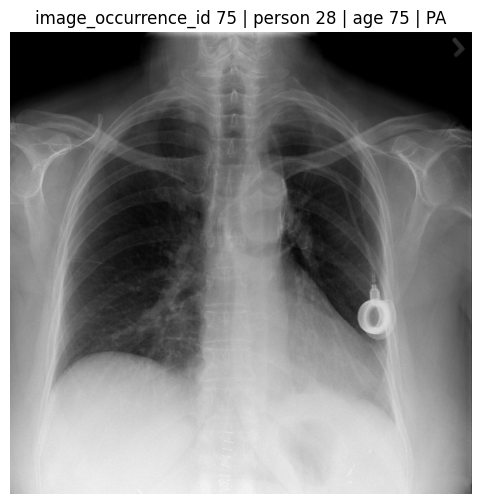

In [ ]:
import pydicom
import matplotlib.pyplot as plt
from pydicom.pixel_data_handlers.util import apply_voi_lut

if hits.empty:
    print("No matching images.")
else:
    row = hits.iloc[0]
    ds = pydicom.dcmread(row.local_path)
    img = apply_voi_lut(ds.pixel_array, ds)            # apply window/LUT if present
    if ds.get("PhotometricInterpretation") == "MONOCHROME1":
        img = img.max() - img                          # MONOCHROME1: invert so bone is white

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"image_occurrence_id {row.image_occurrence_id} | person {row.person_id} | "
              f"age {row.age} | {ds.get('ViewPosition', '')}")
    plt.axis("off")
    plt.show()

## Summary — what notebook 02 inherits

| Table | Rows | Grain |
|---|---|---|
| `person` | one per DICOM Patient ID | patient |
| `procedure_occurrence` | one per study | procedure |
| `image_occurrence` | one per series | **imaging catalog** (MI-CDM) |
| `measurement` (type 32817) | one per attribute value | DICOM acquisition metadata |

➡ Continue with **Notebook 02. Image-derived features**.

In [ ]:
# Optional: download the database to your computer
try:
    from google.colab import files
    files.download(DB_PATH)
except ImportError:
    print("Not on Colab — database is at", DB_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>